In [1]:
from skimage.util import montage
import matplotlib.pyplot as plt
from natsort import natsorted
from anndata import AnnData
import seaborn as sns
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import tifffile
import anndata
import zipfile
import copy
import os
import glob
import sys

sys.path.insert(0, '/home/maa7095/pipelines/spatial_fluorescence_projects/utils')

import utils

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

# Disable auto-scrolling
from IPython.display import display, HTML
display(HTML("<style>div.output_scroll { height: auto; max-height: none; }</style>"))

In [2]:
sample_name = "S24-22889_A6"
region = "tumor_inner"

In [3]:


# Path to folder containing your CSVs
file_object = "/local/storage/maa7095/Raw_data_projects/Spatial_data/COMET/raw_data_sept2025/20250114_191808_1_b5mGMb_ERIKA_P1_OPT2_S24-22889_A6.tiff_object_Data.csv"
data_raw = pd.read_csv(file_object)
pd.crosstab(data_raw['Image Location'], data_raw['Analysis Region'])




Analysis Region,entire image,peritumoral_area,tumor_inner
Image Location,,,
E:\Shah COMET Images\20250114_191808_1_b5mGMb_ERIKA_P1_OPT2_S24-22889_A6\20250114_191808_1_b5mGMb_ERIKA_P1_OPT2_S24-22889_A6.tiff,917517,45740,315060


In [4]:
data_raw['sample_name']=sample_name
data_raw = data_raw.drop(columns=['Image Location'])


In [5]:
region_interest = data_raw[data_raw['Analysis Region']==region]

In [6]:
Image_6679_C_area = region_interest

In [7]:
Image_6679_C_area.shape

(315060, 205)

In [8]:
Image_6679_C_area.index = Image_6679_C_area['Object Id'].values

In [9]:
Image_6679_C_area['xmean']=Image_6679_C_area[["XMax", "XMin"]].mean(axis=1, skipna=True)
Image_6679_C_area['ymean']=Image_6679_C_area[["YMax", "YMin"]].mean(axis=1, skipna=True)


In [10]:
Image_6679_C_area.columns[Image_6679_C_area.columns.str.contains("TRITIC")]

Index([], dtype='object')

In [11]:
Image_6679_C_area.columns[Image_6679_C_area.columns.str.contains("Area")]

Index(['Cell Area (µm²)', 'Cytoplasm Area (µm²)', 'Membrane Area (µm²)',
       'Nucleus Area (µm²)'],
      dtype='object')

In [12]:
Image_6679_C_area

,Analysis Region,Algorithm Name,Object Id,CD138 1K Cell Intensity,CD138 1K Cytoplasm Intensity,CD138 1K Nucleus Intensity,CD138 1K Positive Classification,CD138 1K Positive Cytoplasm Classification,CD138 1K Positive Nucleus Classification,CD163 2000 Cell Intensity,...,VIMENTIN 2k ARVIN Positive Classification,VIMENTIN 2k ARVIN Positive Cytoplasm Classification,VIMENTIN 2k ARVIN Positive Nucleus Classification,XMax,XMin,YMax,YMin,sample_name,xmean,ymean
0,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,0,224.54967,219.12073,229.16386,0,0,0,182.18709,...,0,0,0,5450,5395,3696,3665,S24-22889_A6,5422.5,3680.5
1,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,1,194.45090,198.29639,187.06087,0,0,0,163.38245,...,0,0,0,5028,4999,3697,3665,S24-22889_A6,5013.5,3681.0
2,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,2,228.70975,235.37163,219.18358,0,0,0,180.26640,...,0,0,0,4841,4816,3698,3670,S24-22889_A6,4828.5,3684.0
3,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,3,212.65958,214.02065,209.98648,0,0,0,175.08662,...,0,0,0,4984,4959,3700,3667,S24-22889_A6,4971.5,3683.5
4,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,4,258.18198,265.51514,250.16887,0,0,0,191.92880,...,0,0,0,5118,5093,3708,3675,S24-22889_A6,5105.5,3691.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,315055,235.22787,213.10861,261.17548,0,0,0,178.73009,...,0,0,0,15039,15003,29822,29790,S24-22889_A6,15021.0,29806.0
315056,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,315056,248.37427,261.46280,241.20815,0,0,0,176.30410,...,0,0,0,15090,15061,29835,29807,S24-22889_A6,15075.5,29821.0
315057,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,315057,197.59378,204.42210,192.19086,0,0,0,165.49501,...,0,0,0,15083,15047,29851,29812,S24-22889_A6,15065.0,29831.5
315058,tumor_inner,segmentation_cells_v1.4_S24-22889_A6,315058,251.47357,271.96475,215.95555,0,0,0,167.66463,...,0,0,0,15031,15002,29840,29821,S24-22889_A6,15016.5,29830.5


In [13]:
cell_area = Image_6679_C_area['Cell Area (µm²)']
# Define threshold for the lowest 2%
threshold_area = cell_area.quantile(0.02)
Image_6679_C_area_sub = Image_6679_C_area[cell_area > threshold_area]

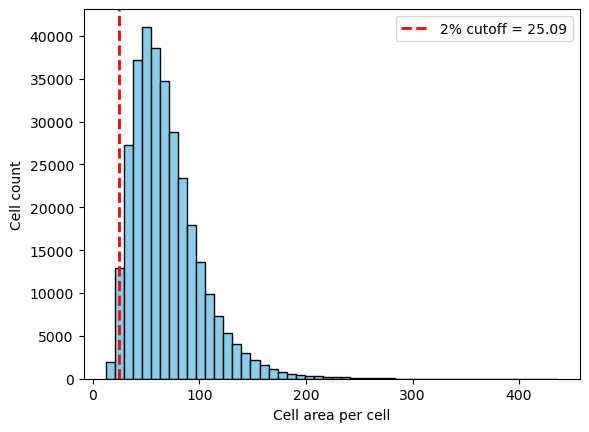

In [14]:

plt.hist(cell_area, bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold_area, color='red', linestyle='dashed', linewidth=2, label=f'2% cutoff = {threshold_area:.2f}')
plt.xlabel("Cell area per cell")
plt.ylabel("Cell count")
plt.title("")
plt.legend()
plt.show()



In [15]:
dapi_mean = Image_6679_C_area_sub['DAPI Cell Intensity']
# Define threshold for the lowest 2%
threshold = dapi_mean.quantile(0.02)
Image_6679_C_area_sub = Image_6679_C_area_sub[dapi_mean > threshold]

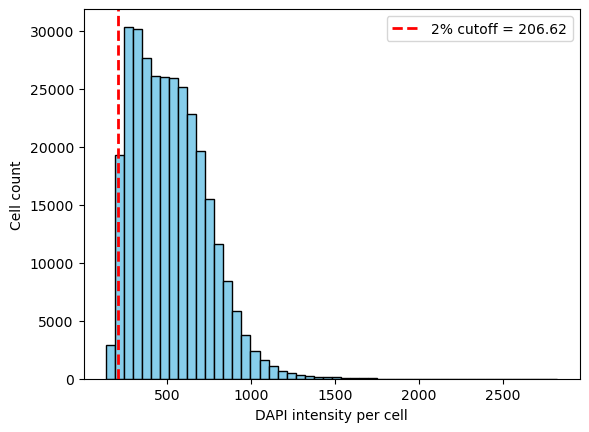

In [16]:

plt.hist(dapi_mean, bins=50, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'2% cutoff = {threshold:.2f}')
plt.xlabel("DAPI intensity per cell")
plt.ylabel("Cell count")
plt.title("")
plt.legend()
plt.show()



In [17]:
# add lymphonde or colon annotation
Image_6679_C_area_sub['annotation'] = region

In [18]:
max(Image_6679_C_area_sub['DAPI Cell Intensity'].values)

2824.5823

In [19]:
min(Image_6679_C_area_sub['DAPI Cell Intensity'].values)

206.61818

## Check how the tissue looks.

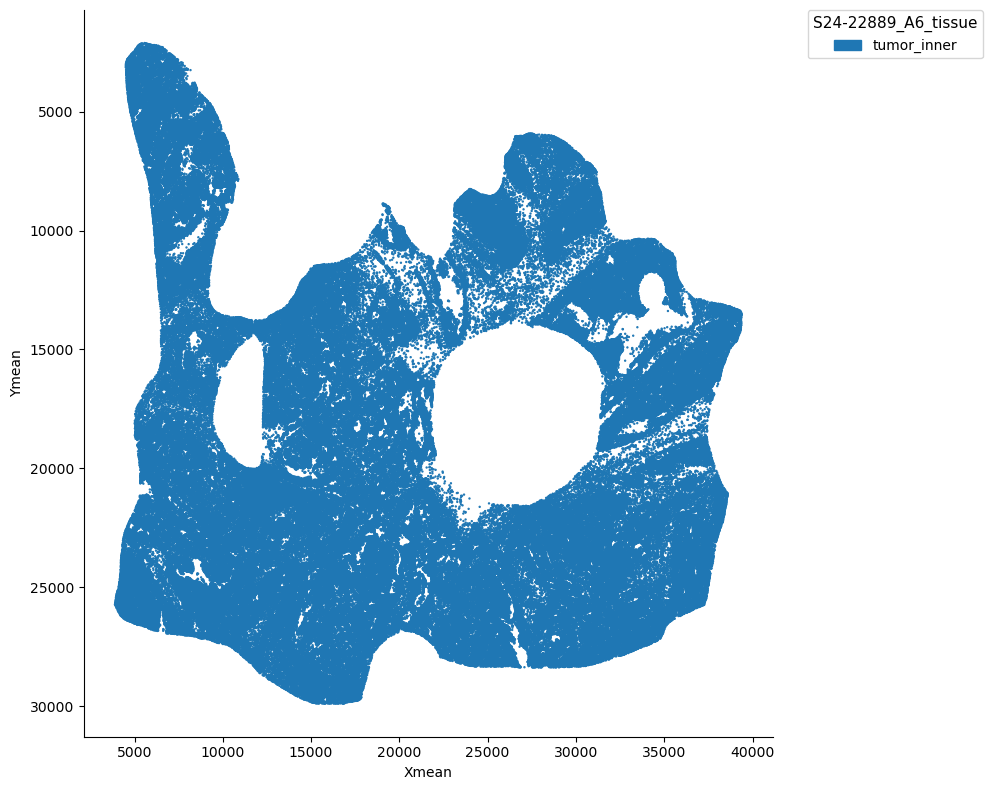

In [20]:
fig, ax = plt.subplots(figsize=(10,8))
unique_annotations = Image_6679_C_area_sub['annotation'].unique()
palette = sns.color_palette('tab10', n_colors=len(unique_annotations))
annotation_colors = dict(zip(unique_annotations, palette))

# Map annotation column to color values
colors = Image_6679_C_area_sub['annotation'].map(annotation_colors)

ax.scatter(
        Image_6679_C_area_sub['xmean'],
        Image_6679_C_area_sub['ymean'],
        color=colors,
        s=0.5  # size of the points
    )
#ax.invert_xaxis()
ax.invert_yaxis()

# Customize legend
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color, label=label) for label, color in annotation_colors.items()]
ax.legend(
    handles=legend_handles,
    title=f'{sample_name}_tissue',
    fontsize=10,
    title_fontsize=11,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.
)
# Aesthetics
sns.despine()
plt.xlabel('Xmean')
plt.ylabel('Ymean')
plt.title('')
plt.subplots_adjust(right=0.75)

plt.tight_layout()
plt.show()

In [21]:
Image_6679_C_area_sub.index = Image_6679_C_area_sub['Object Id'].values

In [22]:
Image_6679_C_area_sub.columns

Index(['Analysis Region', 'Algorithm Name', 'Object Id',
       'CD138 1K Cell Intensity', 'CD138 1K Cytoplasm Intensity',
       'CD138 1K Nucleus Intensity', 'CD138 1K Positive Classification',
       'CD138 1K Positive Cytoplasm Classification',
       'CD138 1K Positive Nucleus Classification', 'CD163 2000 Cell Intensity',
       ...
       'VIMENTIN 2k ARVIN Positive Cytoplasm Classification',
       'VIMENTIN 2k ARVIN Positive Nucleus Classification', 'XMax', 'XMin',
       'YMax', 'YMin', 'sample_name', 'xmean', 'ymean', 'annotation'],
      dtype='object', length=208)

In [23]:
Image_6679_C_intensities = Image_6679_C_area_sub.filter(regex="Cytoplasm Intensity|Nucleus Intensity")

In [24]:
Image_6679_C_intensities = Image_6679_C_intensities.loc[:, ~Image_6679_C_intensities.columns.str.contains("LICOR")]

In [25]:
markers_nucleus_only = ['FOXP3', 'PCNA', 'PAX5', 'MKI67']
cytoplasm_cols = [col for col in Image_6679_C_intensities.columns
                  if 'Cytoplasm Intensity' in col and not any(marker in col for marker in markers_nucleus_only)]
nucleus_cols = [col for col in Image_6679_C_intensities.columns
                if 'Nucleus Intensity' in col and any(marker in col for marker in markers_nucleus_only)]
selected_cols = cytoplasm_cols + nucleus_cols
Image_6679_C_intensities = Image_6679_C_intensities[selected_cols]


In [26]:
neg_probes_Image_6679_C= Image_6679_C_area_sub[
    ['LICOR Diluent -  RB Cell Intensity', 'LICOR Diluent -  MS Cell Intensity']
].rename(columns={
    'LICOR Diluent -  RB Cell Intensity': 'LICOR_RB',
    'LICOR Diluent -  MS Cell Intensity': 'LICOR_MS'
})

# Concatenate the renamed LICOR columns with the original intensities DataFrame
intensities_Image_6679_C = pd.concat(
    [Image_6679_C_intensities, neg_probes_Image_6679_C], axis=1
)

In [27]:
intensities_Image_6679_C.columns = [
    col.split(" ")[0] for col in intensities_Image_6679_C.columns
]
intensities_Image_6679_C.columns

Index(['CD138', 'CD163', 'CD20', 'CD206-MRC1-3500', 'CD34', 'CD3E', 'CD4',
       'CD45RA', 'CD68', 'CD8', 'CTLA-4', 'ECAD', 'GZMB', 'ICOS', 'IDO',
       'LAG3', 'NCAM1', 'panCK', 'PD-1', 'PDL1', 'Podoplanin', 'SMA', 'TIM-3',
       'TNFRSF8-CD30', 'VIMENTIN', 'FOXP3', 'MKI67', 'PAX5', 'PCNA',
       'LICOR_RB', 'LICOR_MS'],
      dtype='object')

In [28]:
dup_intensities_Image_6679_C = intensities_Image_6679_C.copy()

In [29]:
#intensities_Image_6679_C = intensities_Image_6679_C.drop(columns=['CD20', 'CD206-MRC1'])
#dup_intensities_Image_6679_C = dup_intensities_Image_6679_C.drop(columns=['CD20', 'CD206-MRC1'])
dup_intensities_Image_6679_C

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA,LICOR_RB,LICOR_MS
0,219.12073,181.44685,158.78738,163.50090,242.12433,183.51892,208.61261,220.07748,259.26306,222.84145,...,230.79820,212.13153,210.62343,245.61441,151.43033,269.86218,177.96172,644.86830,124.753310,109.152320
1,198.29639,167.79185,154.88235,164.41855,214.70815,170.22173,195.52263,199.35747,230.11313,198.40950,...,207.21494,196.50905,197.28280,224.64253,136.26521,179.84782,156.13913,281.87390,123.718750,108.620540
2,235.37163,183.38852,179.02026,167.44257,262.39865,185.58784,221.60811,229.38513,282.39190,239.02702,...,252.77365,228.36148,230.74663,262.23987,157.19324,191.73430,168.71980,281.88406,126.914510,120.041750
3,214.02065,176.58945,159.02065,161.64450,232.64450,175.04129,204.55734,206.10550,250.76834,212.84862,...,221.36926,208.45413,203.76834,230.52065,147.29730,196.17567,173.68468,271.17570,125.598785,114.250760
4,265.51514,194.75151,178.39091,171.79697,278.92120,197.10909,243.46970,239.31516,303.72122,250.04546,...,263.30908,238.76970,239.75455,282.63940,153.60265,213.24503,184.90067,299.64902,124.183550,115.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,213.10861,175.92418,147.88524,179.65984,223.79099,180.19263,200.60040,197.60450,232.47950,192.77254,...,210.11476,204.43237,195.29918,236.22336,142.71875,236.37980,177.79327,717.63940,122.933630,98.692474
315056,261.46280,181.18182,147.20660,160.70248,229.06612,178.80165,198.86777,218.52066,236.79340,203.42975,...,220.54546,198.33884,193.68594,235.74380,137.15837,294.26697,169.61990,1183.10410,119.336260,96.038010
315057,204.42210,170.63818,143.02513,158.27386,215.16583,173.93468,197.35176,204.73870,226.12814,191.60553,...,210.34170,196.13818,191.55276,223.08543,131.10934,203.25645,160.63420,734.47910,119.289680,93.211990
315058,271.96475,170.21474,139.90706,152.54808,225.73077,174.83653,197.53526,217.87500,236.81730,201.93910,...,216.12500,195.93270,186.84294,236.08974,131.15555,385.78333,162.08888,1123.26110,118.776420,93.563010


## Run first binary to ientify cells expressing all the mouse or rat probes.

After we idenitfy them we remove those cells from the matrix and rerun the thresholding.

In [30]:
#function from utils.py so from lunaphore
def get_binary_cells(z_norm_data: np.ndarray,
                     peak_range: tuple = None,
                     sigma_mult: float = 1.0) -> np.ndarray:
    """
    Generate a binary matrix indicating cells that are positive

    Parameters:
        - z_norm_data (numpy.ndarray): 2D array of normalized expression values (markers x cells).
        - peak_range (tuple): Range of the histogram to be used for a peak search.
        - sigma_mult (float): Multiplier for computed background sigma value.


    Returns:
        - numpy.ndarray: Binary matrix indicating cells that are positive.
    """

    # Compute thresholds
    thresholds, _ = get_thresholds(z_norm_data, peak_range, sigma_mult)

    # Transpose the input data for marker-wise processing
    z_norm_data_tr = np.transpose(z_norm_data)

    # Create a binary matrix for positive cells
    markers_norm_frame = [column > threshold for column, threshold in zip(z_norm_data_tr, thresholds)]

    # Transpose the binary matrix back to the original orientation
    return np.transpose(markers_norm_frame)


In [31]:
#funcrtion to set up the thresholds for each one
def get_thresholds(markers_counts: np.ndarray,
                   peak_range: tuple = None,
                   sigma_mult: float = 1.0) -> tuple:
    """
    Get thresholds from Z-normalized marker expression data.
    The assumption here is that the first peak in image histogram is related to background and
    the background is normally distributed.
    Thresholds and background values are calculated column-wise.

    Parameters:
        - markers_counts (numpy.ndarray): Input array containing Z-norm marker counts.
        - peak_range (tuple): Range of the histogram to be used for a peak search
        - sigma_mult (float): Multiplier for computed background sigma value.

    Returns:
        - numpy.ndarray: Thresholds for each marker
        - numpy.ndarray: Background values
    """
    import random

    # Set the seed
    random.seed(42)

    # Check peak search parameters
    if peak_range is None:
        peak_range = (np.min(markers_counts), np.max(markers_counts))

    # Transpose. Data should be z-normalized already
    markers_counts = np.transpose(markers_counts)

    # Create empty lists for thresholds and background peaks
    marker_thresholds = []
    background_values = []

    # Iterate through all the markers
    for marker in markers_counts:

        # Make a histogram
        hist = np.histogram(marker, bins=1000, range=peak_range)
        
        # Get histogram bars and
        hist_values = hist[0]
        bin_edges = hist[1]

        # Get bin centers
        bin_centers = np.cumsum(np.diff(bin_edges)) + bin_edges[0]

        # Smooth histogram for peak finding
        smoothed_histogram = gaussian_filter1d(hist_values, 5)

        # Look for the first peak in the histogram (background peak)
        peaks, _ = find_peaks(smoothed_histogram, prominence=50)

        if len(peaks) > 0:
            background_peak_index = peaks[0]

            # Get first peak width in bins
            hist_first_peak_width = peak_widths(smoothed_histogram, np.array([background_peak_index]), rel_height=0.5)

            # Compute real peak width
            peak_width = hist_first_peak_width[0][0] * np.mean(np.diff(bin_centers))

            # Assume that it is a normal distribution and compute sigma. Simply divide by 2.355
            sigma = peak_width / round(2 * np.sqrt(2 * np.log(2)), 3)

            # Append values to corresponding arrays
            marker_thresholds.append(bin_centers[background_peak_index] + sigma * sigma_mult)
            background_values.append(bin_centers[background_peak_index])

        # If no peaks are found add None
        else:
            marker_thresholds.append(None)
            background_values.append(None)
            

    return np.asarray(marker_thresholds), np.asarray(background_values)

In [32]:
channel_probes = pd.read_csv("/SSD/maa7095/spatial_techniques/manish_comet/ROI_analysis/markers_channels.csv")

In [33]:
rabbit_markers = channel_probes[channel_probes.background=='LICOR Diluent - RB']['marker_name'].unique()
rabbit_markers = [
    col.split(" ")[0] for col in rabbit_markers
]

In [34]:
mouse_markers = channel_probes[channel_probes.background=='LICOR Diluent - MS']['marker_name'].unique()
mouse_markers = [
    col.split(" ")[0] for col in mouse_markers
]

## Run now sigma threshold after all the filtering

In [35]:
intensities_Image_6679_C = intensities_Image_6679_C.loc[:, ~intensities_Image_6679_C.columns.str.contains("LICOR")]

In [36]:
# add arsinc log transfor data
tot_counts_per_cell = dup_intensities_Image_6679_C.sum(axis=1)
# Step 2: Normalize intensities (similar to COSMx normalization)
arcsin_intensities = ((dup_intensities_Image_6679_C.T/tot_counts_per_cell) * 10000).T
# Step 3: Apply the log transformation
log_intensities = np.log(arcsin_intensities / 10 + np.sqrt((arcsin_intensities / 10) ** 2 + 1))


In [37]:
dup_intensities_Image_6679_C

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA,LICOR_RB,LICOR_MS
0,219.12073,181.44685,158.78738,163.50090,242.12433,183.51892,208.61261,220.07748,259.26306,222.84145,...,230.79820,212.13153,210.62343,245.61441,151.43033,269.86218,177.96172,644.86830,124.753310,109.152320
1,198.29639,167.79185,154.88235,164.41855,214.70815,170.22173,195.52263,199.35747,230.11313,198.40950,...,207.21494,196.50905,197.28280,224.64253,136.26521,179.84782,156.13913,281.87390,123.718750,108.620540
2,235.37163,183.38852,179.02026,167.44257,262.39865,185.58784,221.60811,229.38513,282.39190,239.02702,...,252.77365,228.36148,230.74663,262.23987,157.19324,191.73430,168.71980,281.88406,126.914510,120.041750
3,214.02065,176.58945,159.02065,161.64450,232.64450,175.04129,204.55734,206.10550,250.76834,212.84862,...,221.36926,208.45413,203.76834,230.52065,147.29730,196.17567,173.68468,271.17570,125.598785,114.250760
4,265.51514,194.75151,178.39091,171.79697,278.92120,197.10909,243.46970,239.31516,303.72122,250.04546,...,263.30908,238.76970,239.75455,282.63940,153.60265,213.24503,184.90067,299.64902,124.183550,115.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,213.10861,175.92418,147.88524,179.65984,223.79099,180.19263,200.60040,197.60450,232.47950,192.77254,...,210.11476,204.43237,195.29918,236.22336,142.71875,236.37980,177.79327,717.63940,122.933630,98.692474
315056,261.46280,181.18182,147.20660,160.70248,229.06612,178.80165,198.86777,218.52066,236.79340,203.42975,...,220.54546,198.33884,193.68594,235.74380,137.15837,294.26697,169.61990,1183.10410,119.336260,96.038010
315057,204.42210,170.63818,143.02513,158.27386,215.16583,173.93468,197.35176,204.73870,226.12814,191.60553,...,210.34170,196.13818,191.55276,223.08543,131.10934,203.25645,160.63420,734.47910,119.289680,93.211990
315058,271.96475,170.21474,139.90706,152.54808,225.73077,174.83653,197.53526,217.87500,236.81730,201.93910,...,216.12500,195.93270,186.84294,236.08974,131.15555,385.78333,162.08888,1123.26110,118.776420,93.563010


In [38]:
log_intensities.index.equals(dup_intensities_Image_6679_C.index)


True

In [39]:
log_intensities

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA,LICOR_RB,LICOR_MS
0,4.107055,3.918519,3.785243,3.814466,4.206835,3.929865,4.057939,4.111410,4.275198,4.123884,...,4.158950,4.074657,4.067527,4.221140,3.737854,4.315252,3.899141,5.186239,3.544335,3.410996
1,4.199682,4.032732,3.952728,4.012436,4.279165,4.047101,4.185601,4.205016,4.348432,4.200252,...,4.243656,4.190631,4.194559,4.324379,3.824773,4.102078,3.960804,4.551265,3.728282,3.598304
2,4.249591,4.000164,3.976073,3.909264,4.358251,4.012078,4.189362,4.223839,4.431659,4.264996,...,4.320893,4.219368,4.229754,4.357645,3.846154,4.044639,3.916857,4.429860,3.632435,3.576844
3,4.218924,4.026780,3.922061,3.938414,4.302330,4.017980,4.173720,4.181256,4.377322,4.213435,...,4.252669,4.192582,4.169857,4.293162,3.845545,4.131903,4.010205,4.455537,3.686356,3.591790
4,4.280446,3.970663,3.882984,3.845353,4.329686,3.982688,4.193803,4.176600,4.414840,4.220442,...,4.272106,4.174319,4.178433,4.342924,3.733524,4.061322,3.918796,4.401345,3.521218,3.449944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,4.141979,3.950348,3.776885,3.971345,4.190866,3.974304,4.081524,4.066486,4.228939,4.041744,...,4.127838,4.100436,4.054758,4.244908,3.741363,4.245569,3.960908,5.355914,3.592327,3.373109
315056,4.242773,3.876205,3.668762,3.756375,4.110554,3.862993,3.969271,4.063450,4.143714,3.991936,...,4.072668,3.966610,3.942888,4.139274,3.598160,4.360925,3.810325,5.752181,3.459209,3.242546
315057,4.109758,3.929234,3.752873,3.854078,4.160954,3.948354,4.074579,4.111305,4.210624,4.045047,...,4.138290,4.068414,4.044772,4.197083,3.665988,4.104043,3.868868,5.388485,3.571647,3.325472
315058,4.300487,3.832161,3.636304,3.722695,4.114241,3.858927,3.980896,4.078839,4.162162,4.002930,...,4.070779,3.972756,3.925289,4.159087,3.571805,4.649998,3.783293,5.718633,3.472837,3.234817


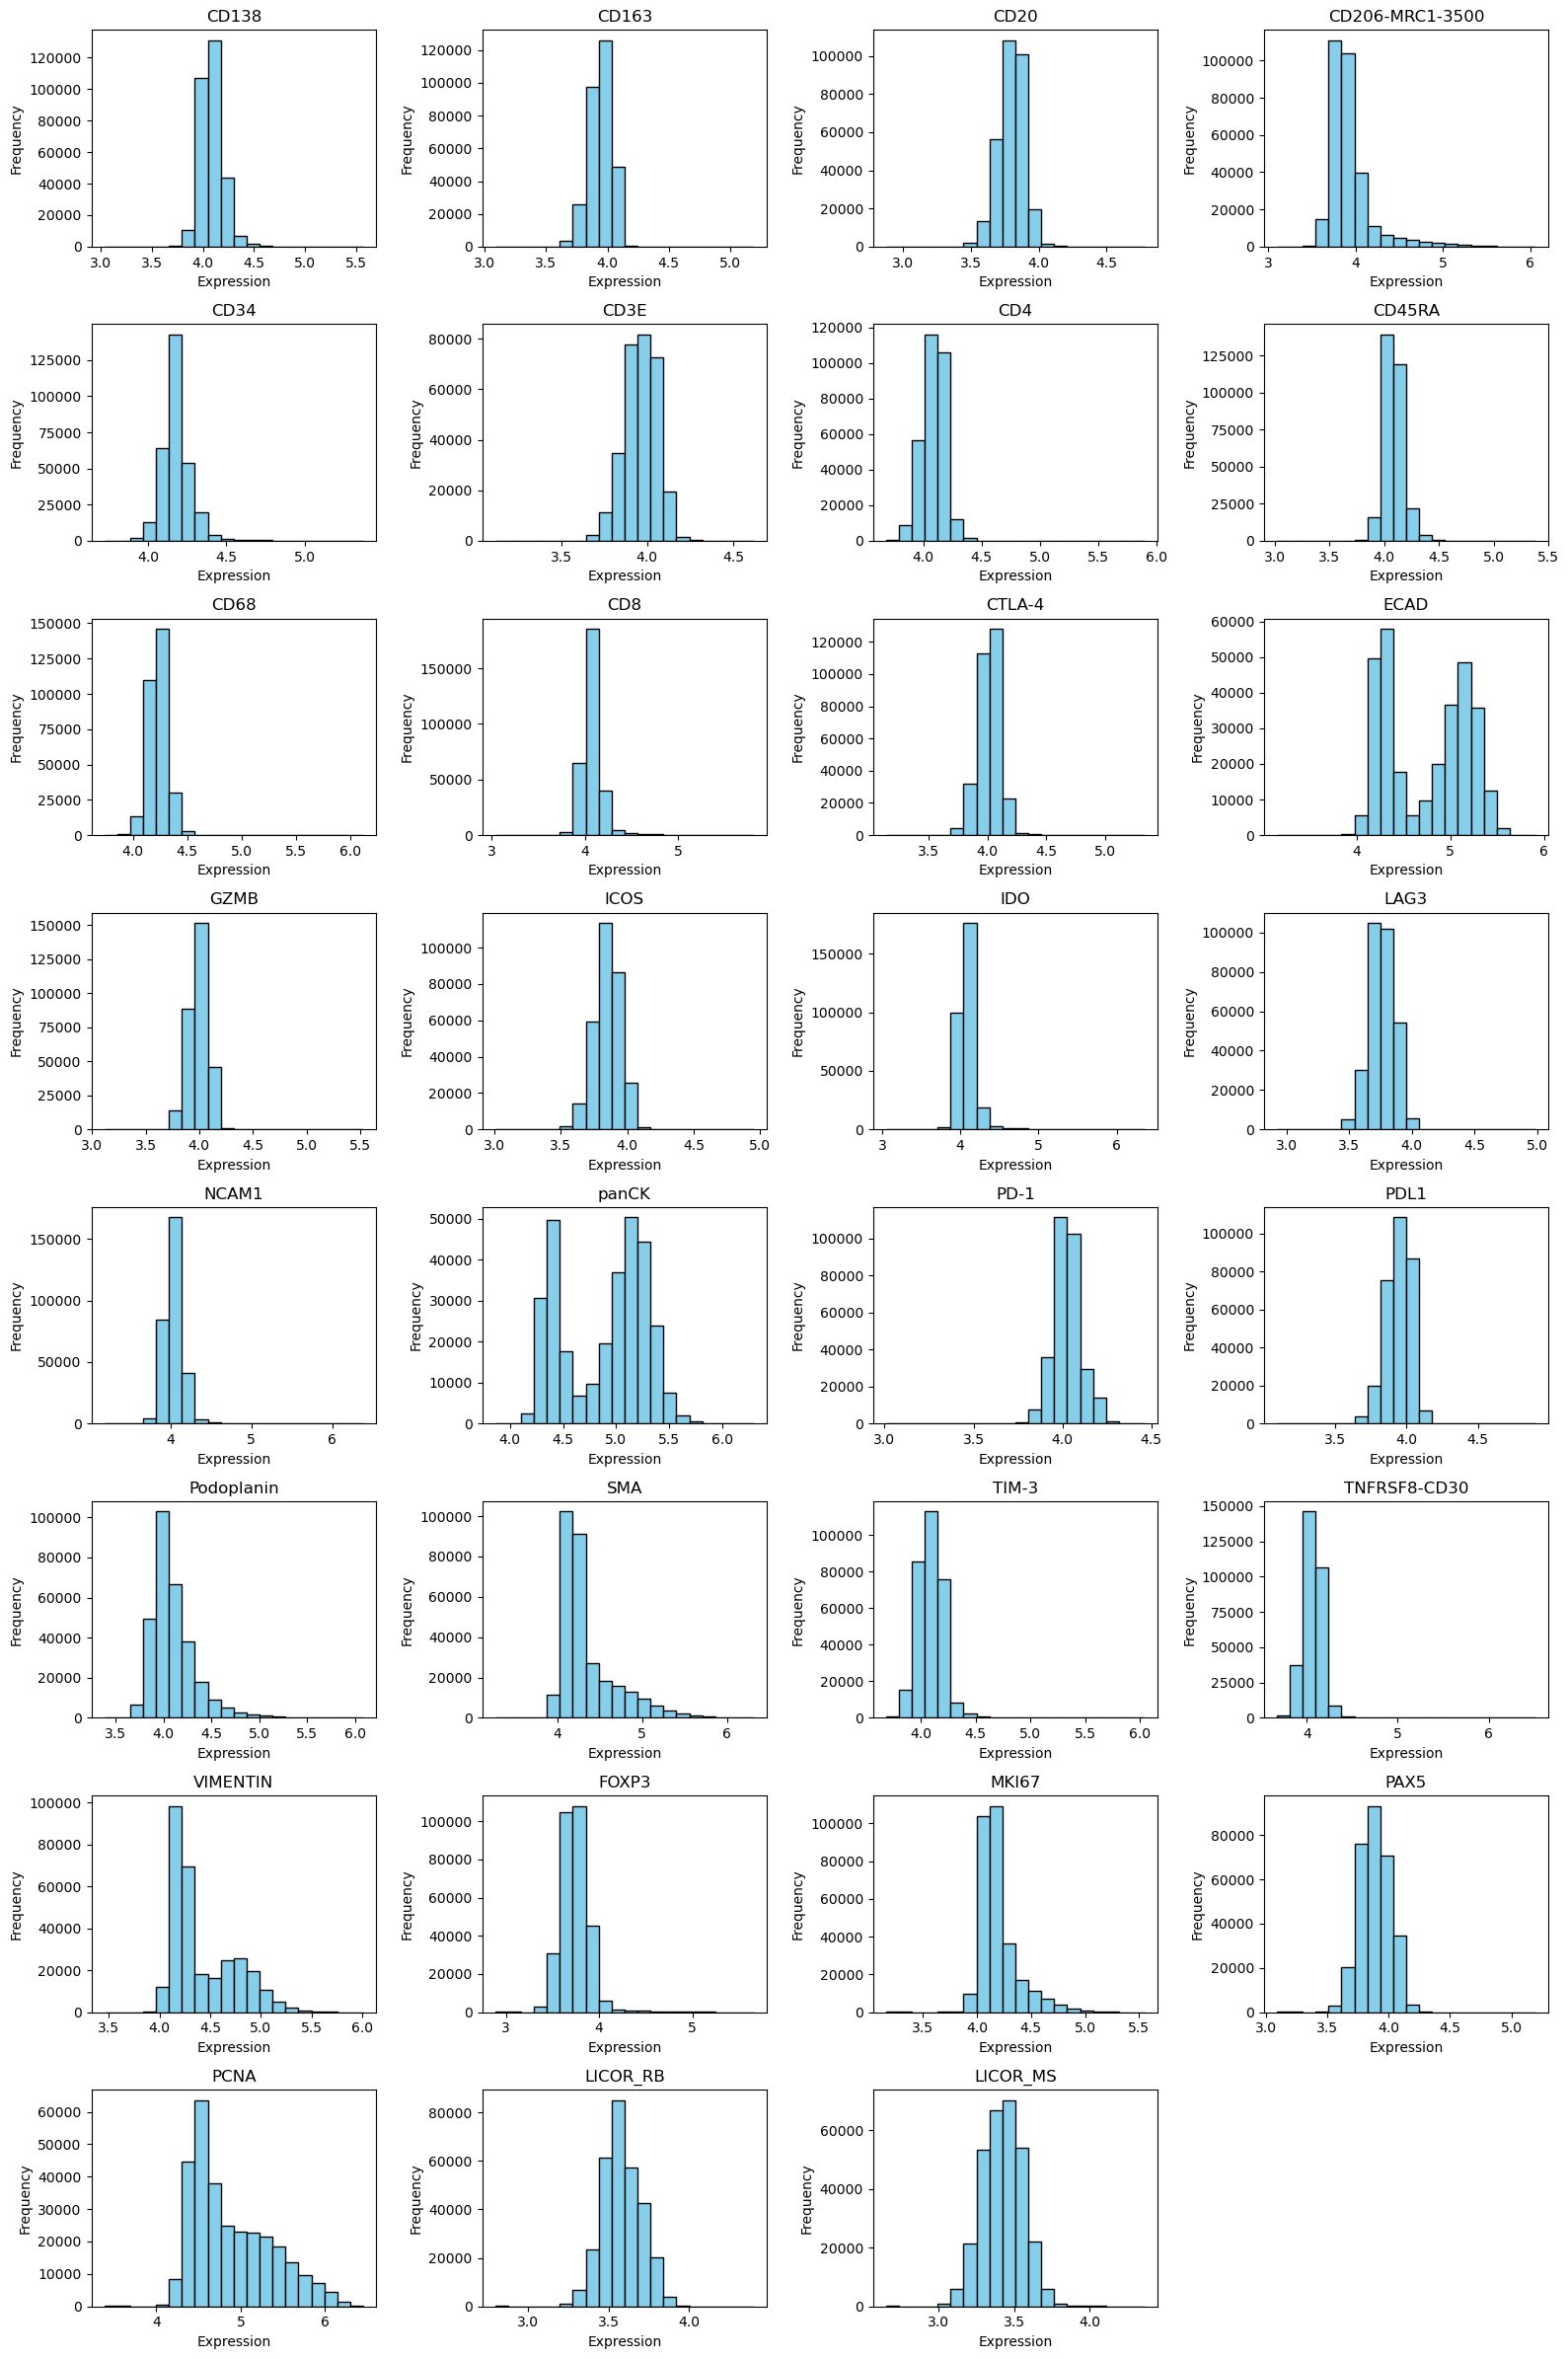

In [40]:
# Parameters
cols_per_row = 4
n_genes = len(log_intensities.columns)
n_rows = (n_genes + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 4, n_rows * 3))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, gene in enumerate(log_intensities.columns):
    axes[i].hist(log_intensities[gene], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(gene)
    axes[i].set_xlabel('Expression')
    axes[i].set_ylabel('Frequency')

# Turn off any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [41]:
# Get all expression data and perform Z-scaling and winsorize
counts_markers_all = intensities_Image_6679_C.to_numpy()
counts_markers_all_norm = utils.normalize_z_scaling(counts_markers_all)
counts_markers_all_norm = utils.winsorize_column_wise(counts_markers_all_norm, [0, 0.0001])


In [42]:
intensities_Image_6679_C

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,PDL1,Podoplanin,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA
0,0.385275,0.402549,0.327696,-0.246086,0.467622,0.267581,0.036281,0.434882,0.600704,0.595123,...,1.568055,-0.461101,-0.428326,0.074405,0.121111,-0.539354,0.193168,0.540909,0.919181,0.287774
1,-0.205162,-0.718326,0.099329,-0.232261,-0.348781,-0.811748,-0.182122,-0.202996,-0.227073,-0.141977,...,0.374375,-0.646483,-0.633101,-0.162387,-0.061697,-0.761394,-0.338712,-0.810419,-0.908488,-0.705658
2,0.846039,0.561931,1.510924,-0.186701,1.071353,0.435515,0.253108,0.721423,1.257498,1.083433,...,1.945241,-0.441224,-0.237511,0.320404,0.396861,-0.363332,0.395288,-0.631975,0.145158,-0.705630
3,0.240671,0.003827,0.341338,-0.274055,0.185330,-0.420546,-0.031380,0.004746,0.359477,0.293644,...,0.802802,-0.460526,-0.510198,0.018666,0.027175,-0.699159,0.048212,-0.565300,0.560973,-0.734937
4,1.700703,1.494665,1.474119,-0.121097,1.563364,1.370692,0.617863,1.027125,1.863191,1.415854,...,2.747689,-0.270751,-0.146031,0.478163,0.520297,-0.147352,0.269357,-0.309048,1.500327,-0.657012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,0.214812,-0.050781,-0.309865,-0.002635,-0.078311,-0.002413,-0.097401,-0.256962,-0.159875,-0.312041,...,-0.137885,0.098198,-0.607922,-0.042292,-0.088878,-0.638782,-0.112370,0.038259,0.905073,0.486931
315056,1.585807,0.380793,-0.349553,-0.288247,0.078773,-0.115318,-0.126309,0.386954,-0.037372,0.009481,...,0.174000,0.021816,-0.517351,-0.134653,-0.110985,-0.643859,-0.307386,0.907283,0.220543,1.760801
315057,-0.031478,-0.484684,-0.594087,-0.324837,-0.335152,-0.510369,-0.151603,-0.037332,-0.340236,-0.347249,...,-0.208139,-0.024064,-0.605951,-0.168009,-0.140216,-0.777879,-0.519541,-0.459001,-0.532021,0.533018
315058,1.883570,-0.519442,-0.776433,-0.411102,-0.020548,-0.437166,-0.148542,0.367077,-0.036693,-0.035491,...,-0.586334,-0.035961,-0.555734,-0.171123,-0.204755,-0.640196,-0.517921,2.281160,-0.410189,1.597024


In [43]:
output_dir = f'{sample_name}_{region}_sigma_binary_res'
os.makedirs(output_dir, exist_ok=True)

In [44]:
df_counts_markers_all_norm = pd.DataFrame(
    counts_markers_all_norm,
    index=intensities_Image_6679_C.index,     # ⬅️ add this line
    columns=intensities_Image_6679_C.columns
)

In [45]:
df_counts_markers_all_norm['cell_id']=df_counts_markers_all_norm.index.values

In [46]:
#save them matrix to work locally with napari
df_counts_markers_all_norm.to_csv(f"{output_dir}/z_score_normalization.csv", index=False)


Winsorization is a way to limit extreme values in your data (outliers) by setting them to a specific percentile.

# Code from Lunaphore to detct for real positivity of markers in the cells

In [47]:
# Prepare parameters for marker thresholding
histogram_range = (np.min(counts_markers_all_norm), np.max(counts_markers_all_norm)/5)
histogram_range

(-4.4866172152477795, 7.806901861836158)

# Code to get the binomial annotation

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths
import os

#save results to work later with them.
binary_tables_dict = {}
thresholds_dict = {}

# Define your sigma values and histogram range
sigma_multipliers = [6]


# Loop through each sigma multiplier
for sigma_multiplier in sigma_multipliers:
    print(f"Processing sigma multiplier: {sigma_multiplier}")
    
    # Thresholding step
    thresholded_marker_table = get_binary_cells(counts_markers_all_norm, histogram_range, sigma_multiplier)
    
    # Save binary result
    df_binary = pd.DataFrame(thresholded_marker_table,  columns=intensities_Image_6679_C.columns,index=intensities_Image_6679_C.index)
    df_binary.to_csv(f"{output_dir}/table_sigma_{sigma_multiplier}.csv", index=False)
    binary_tables_dict[sigma_multiplier] = df_binary

    # For background/threshold plots and values
    markers_counts = np.transpose(counts_markers_all_norm)

    marker_thresholds = []
    background_values = []

    # Plot setup
    n_markers = markers_counts.shape[0]
    n_cols = 4
    n_rows = int(np.ceil(n_markers / n_cols))
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3), sharex=True, sharey=True)

    axs = axs.flatten()

    for idx, marker in enumerate(markers_counts):
        ax = axs[idx]
        
        hist_values, bin_edges = np.histogram(marker, bins=1000, range=histogram_range)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        smoothed_hist = gaussian_filter1d(hist_values, 5)

        peaks, _ = find_peaks(smoothed_hist, prominence=50)

        threshold = None
        background = None

        if len(peaks) > 0:
            background_peak_index = peaks[0]
            background = bin_centers[background_peak_index]
            
            width_info = peak_widths(smoothed_hist, [background_peak_index], rel_height=0.5)
            peak_width = width_info[0][0] * np.mean(np.diff(bin_centers))
            sigma = peak_width / (2 * np.sqrt(2 * np.log(2)))
            
            threshold = background + sigma * sigma_multiplier

        marker_thresholds.append(threshold)
        background_values.append(background)

        # Plotting
        ax.plot(bin_centers, smoothed_hist, color='steelblue', lw=2)
        if background is not None:
            ax.axvline(background, color='gray', linestyle='--', lw=1.5, label='Background')
        if threshold is not None:
            ax.axvline(threshold, color='red', linestyle='--', lw=1.5, label='Threshold')
            ymax = ax.get_ylim()[1]
            ax.text(threshold, ymax * 0.95, f'{threshold:.2f}', color='red', ha='right', va='top', fontsize=8, rotation=90)

        marker_name = intensities_Image_6679_C.columns[idx]
        ax.set_title(marker_name, fontsize=10)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.legend(fontsize=6)

    # Turn off unused subplots
    for j in range(idx + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.suptitle(f"Smoothed Histograms (σ={sigma_multiplier})", fontsize=16, y=1.02)
    plt.savefig(f"{output_dir}/threshold_histograms_sigma_{sigma_multiplier}.png", bbox_inches='tight')
    plt.close()

    # Save thresholds and backgrounds
    thresholds_df = pd.DataFrame({
        'Marker': intensities_Image_6679_C.columns,
        'Threshold': marker_thresholds,
        'Background': background_values
    })
    thresholds_df.to_csv(f"{output_dir}/threshold_values_sigma_{sigma_multiplier}.csv", index=False)
    thresholds_dict[sigma_multiplier] = thresholds_df


Processing sigma multiplier: 6


In [49]:
thresholds_df = thresholds_dict[6]  # assuming it's a DataFrame
thresholds = dict(zip(thresholds_df['Marker'], thresholds_df['Threshold']))

In [50]:
#mouse_markers = [marker for marker in mouse_markers if marker != 'CD20']


In [51]:
mask_mouse = binary_tables_dict[6][mouse_markers].all(axis=1)
mouse_rows_to_remove = binary_tables_dict[6].index[mask_mouse]
len(mouse_rows_to_remove)

1

In [52]:
#rabbit_markers = [marker for marker in rabbit_markers if marker != 'CD206-MRC1']

In [53]:
binary_tables_dict[6]

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,PDL1,Podoplanin,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
315056,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
315057,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
315058,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [54]:
mask_rabbit = binary_tables_dict[6][rabbit_markers].all(axis=1)
rabbit_rows_to_remove = binary_tables_dict[6].index[mask_rabbit]
len(rabbit_rows_to_remove)

5

In [55]:
removing_cells = mouse_rows_to_remove.union(rabbit_rows_to_remove)
clean_binary_table = binary_tables_dict[6].drop(index=removing_cells)
clean_binary_table["cell_id"]=clean_binary_table.index.values

In [56]:
clean_binary_table

,CD138,CD163,CD20,CD206-MRC1-3500,CD34,CD3E,CD4,CD45RA,CD68,CD8,...,Podoplanin,SMA,TIM-3,TNFRSF8-CD30,VIMENTIN,FOXP3,MKI67,PAX5,PCNA,cell_id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,0
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,3
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315055,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,315055
315056,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,315056
315057,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,315057
315058,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,315058


In [57]:
#save this new clean table again.
clean_binary_table.to_csv(f"{output_dir}/table_sigma_6.csv", index=False)

In [58]:
# subset the clean data to work later.
clean_subseted_data_raw = dup_intensities_Image_6679_C.loc[dup_intensities_Image_6679_C.index.isin(clean_binary_table['cell_id'])]
clean_subseted_data_raw['cell_id'] = clean_subseted_data_raw.index.values
clean_subseted_data_raw.to_csv(f"{output_dir}/raw_adata.csv", index=False)

In [59]:
sub_metadata = Image_6679_C_area.loc[Image_6679_C_area.index.isin(clean_binary_table['cell_id'])]

In [60]:
# do the same with the metadata
select_columns=['XMax', 'XMin','YMax', 'YMin', 'sample_name', 'xmean', 'ymean', 'Object Id', 'Cell Area (µm²)']
sub_metadata_2 = sub_metadata[select_columns]
sub_metadata_2.to_csv(f"{output_dir}/raw_metadata.csv", index=False)